# Marketing Campaign Performance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url="https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"
df=pd.read_csv(url)

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [4]:
df.shape

(22029, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [6]:
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


In [7]:
df['Campaign_ID'].unique()

array([    1,     2,     3, ..., 22027, 22028, 22029])

In [8]:
df['Location'].unique()

array(['Houston', 'Washington, D.C.', 'Miami', 'Seattle', 'Chicago',
       'Los Angeles', 'Atlanta', 'Dallas', 'New York', 'San Francisco'],
      dtype=object)

In [9]:
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

In [10]:
df['Campaign_Type'].value_counts()

Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64

In [11]:
df['Channel_Used'].value_counts()

Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64

In [12]:
# Best Customer segment
df.groupby('Customer_Segment')['Conversion_Rate'].mean().sort_values(ascending=False)

Customer_Segment
Health & Wellness      4.769554
Foodies                4.766479
Fashionistas           4.760732
Outdoor Adventurers    4.747231
Tech Enthusiasts       4.742282
Name: Conversion_Rate, dtype: float64

In [13]:
#Channel ROI distribution
df.groupby('Channel_Used')['ROI'].sum()

Channel_Used
Email         673804.39
Facebook      704684.82
Google Ads    678232.24
Instagram     646462.11
Website       664577.42
YouTube       660542.33
Name: ROI, dtype: float64

In [14]:
# Acquisition cost by segment
df.groupby('Customer_Segment')['Acquisition_Cost'].mean()

Customer_Segment
Fashionistas           5560.923179
Foodies                5455.679890
Health & Wellness      5556.538426
Outdoor Adventurers    5528.654805
Tech Enthusiasts       5510.690644
Name: Acquisition_Cost, dtype: float64

In [15]:
# Language Comparison
df.groupby('Language')['ROI'].mean()

Language
English     181.478953
French      185.087991
German      185.410112
Mandarin    184.939672
Spanish     180.343173
Name: ROI, dtype: float64

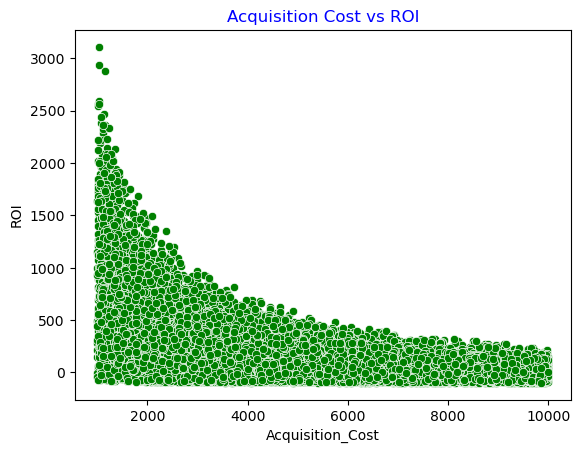

In [16]:
sns.scatterplot(x='Acquisition_Cost', y='ROI', data=df, color='g')
plt.title('Acquisition Cost vs ROI', color='b')
plt.show()

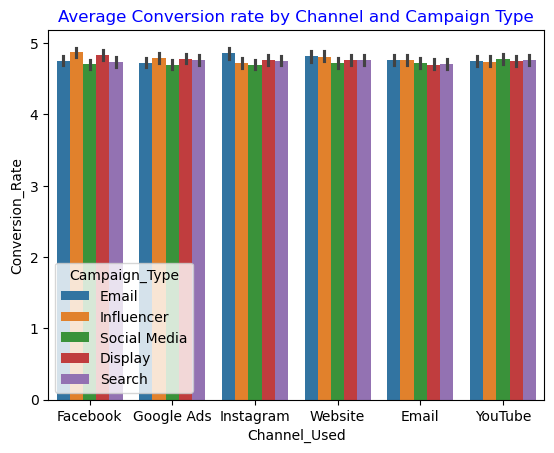

In [17]:
sns.barplot(data=df, x='Channel_Used', y='Conversion_Rate', hue='Campaign_Type')
plt.title('Average Conversion rate by Channel and Campaign Type', color='b')
plt.show()

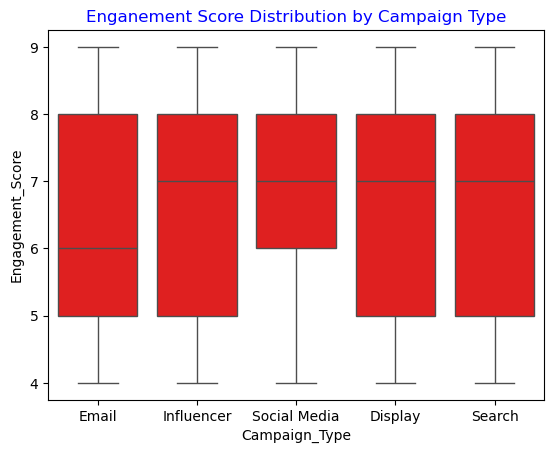

In [18]:
sns.boxplot(data=df, x='Campaign_Type', y='Engagement_Score',color='r')
plt.title('Enganement Score Distribution by Campaign Type', color='b')
plt.show()

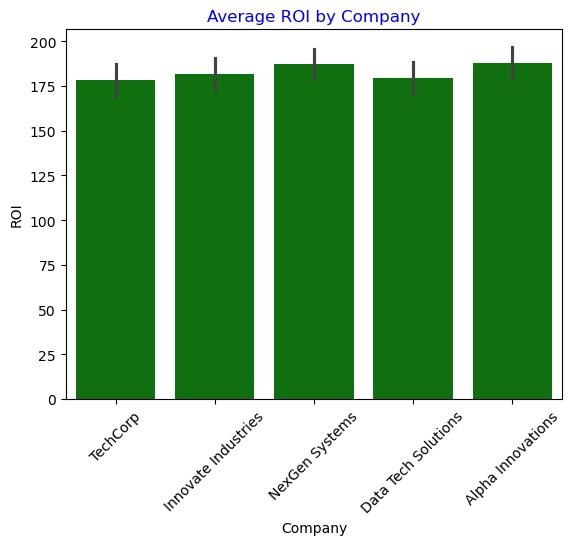

In [19]:
sns.barplot(data=df, x='Company', y='ROI', color='g')
plt.title('Average ROI by Company', color='b')
plt.xticks(rotation=45)
plt.show()

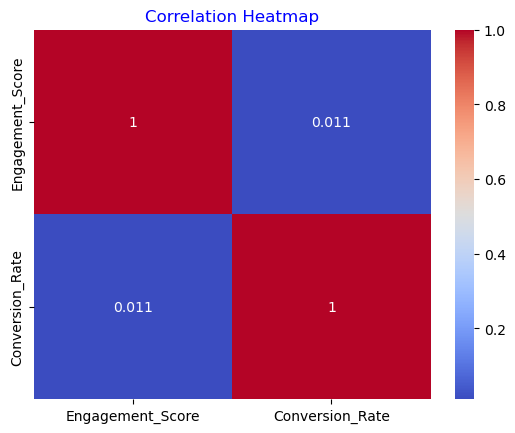

In [20]:
corr = df[['Engagement_Score','Conversion_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', color='b')
plt.show()          

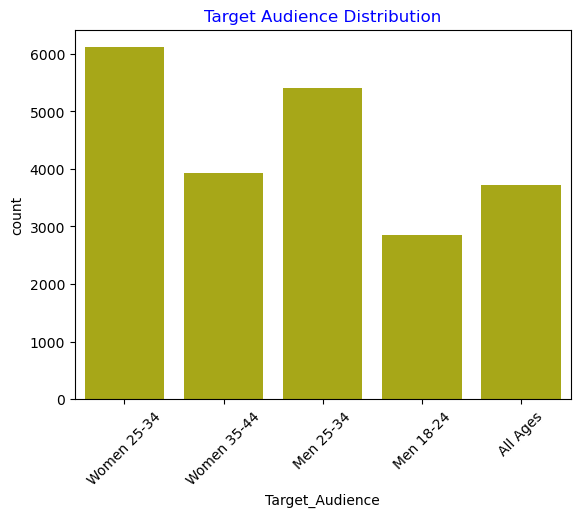

In [21]:
sns.countplot(data=df, x='Target_Audience',color='y')
plt.title('Target Audience Distribution', color='b')
plt.xticks(rotation=45)
plt.show()

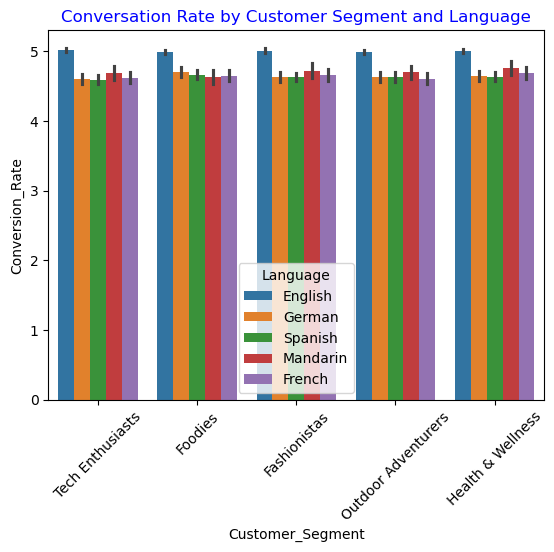

In [22]:
sns.barplot(data=df, x='Customer_Segment', y= 'Conversion_Rate', hue= 'Language')
plt.title('Conversation Rate by Customer Segment and Language', color='b')
plt.xticks(rotation=45)
plt.show()

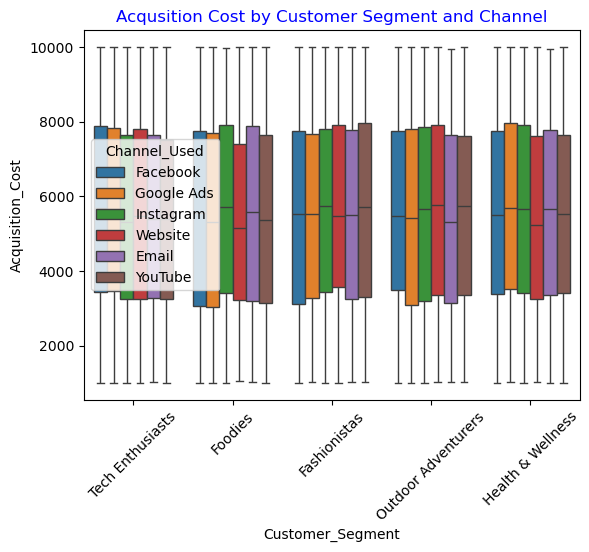

In [23]:
sns.boxplot(data=df, x='Customer_Segment', y='Acquisition_Cost', hue='Channel_Used')
plt.title('Acqusition Cost by Customer Segment and Channel', color='b')
plt.xticks(rotation=45)
plt.show()

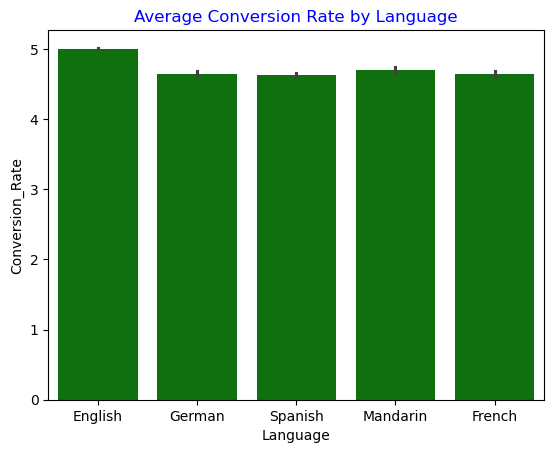

In [24]:
sns.barplot(data=df, x='Language', y='Conversion_Rate', color='g')
plt.title('Average Conversion Rate by Language', color='b')
plt.show()

C:\Users\sitha\AppData\Local\Temp\ipykernel_22532\2019342425.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:y'` for the same effect.

  sns.barplot(data=df, x='Channel_Used', y= 'Engagement_Score', hue='Campaign_Type', color='y')


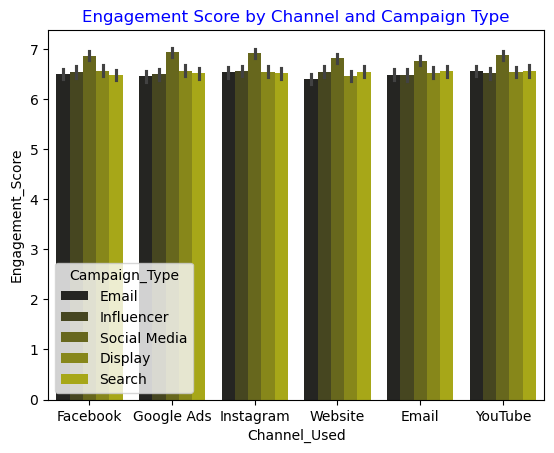

In [25]:
sns.barplot(data=df, x='Channel_Used', y= 'Engagement_Score', hue='Campaign_Type', color='y')
plt.title('Engagement Score by Channel and Campaign Type',color='b')
plt.show()

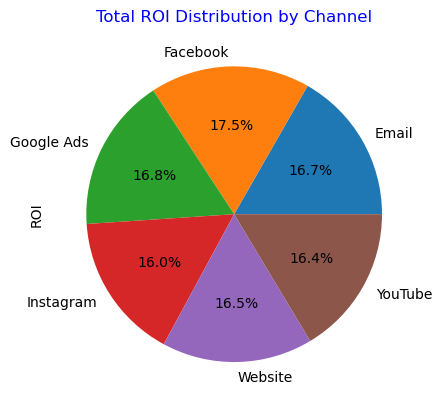

In [26]:
roi_by_channel=df.groupby('Channel_Used')['ROI'].sum()
roi_by_channel.plot.pie(autopct='%1.1f%%')
plt.title('Total ROI Distribution by Channel', color='b')
plt.show()

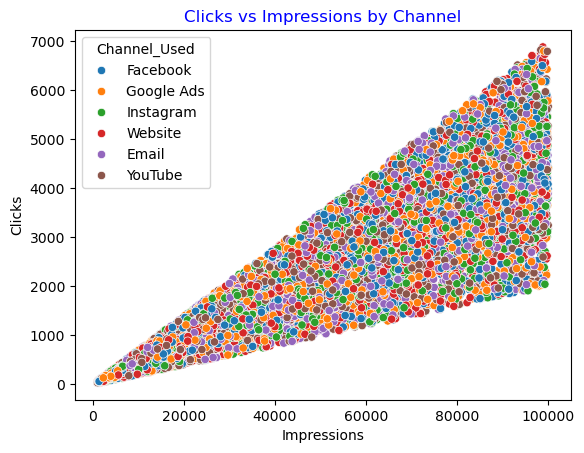

In [27]:
sns.scatterplot(data=df, x='Impressions', y='Clicks', hue='Channel_Used')
plt.title('Clicks vs Impressions by Channel', color='b')
plt.show()

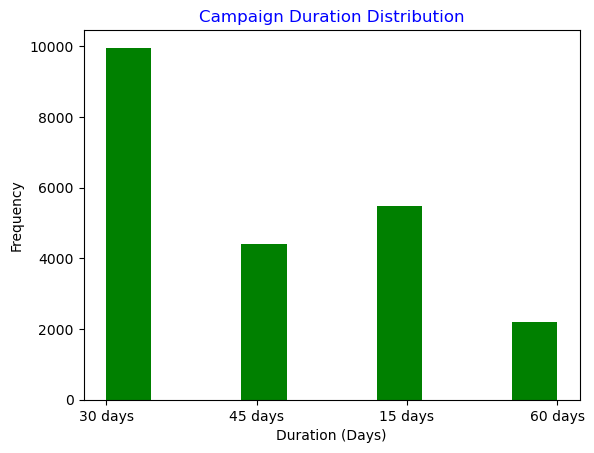

In [28]:
plt.hist(df['Duration'], bins=10, color='g')
plt.title('Campaign Duration Distribution',color='b')
plt.xlabel('Duration (Days)')
plt.ylabel('Frequency')
plt.show()

In [29]:
df['Date']= pd.to_datetime(df['Date'], errors='coerce')

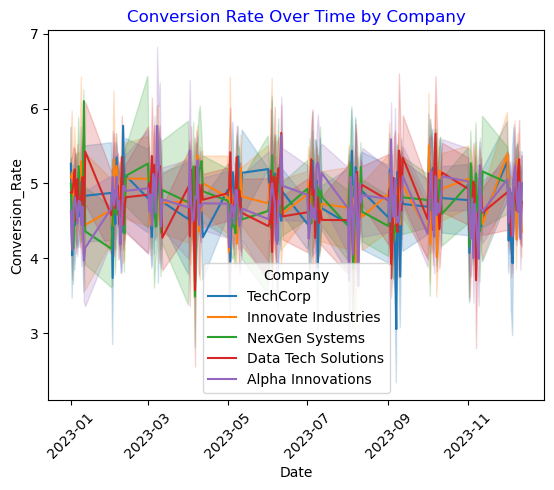

In [30]:
sns.lineplot(data=df, x='Date', y='Conversion_Rate', hue='Company')
plt.title('Conversion Rate Over Time by Company',color='b')
plt.xticks(rotation=45)
plt.show()

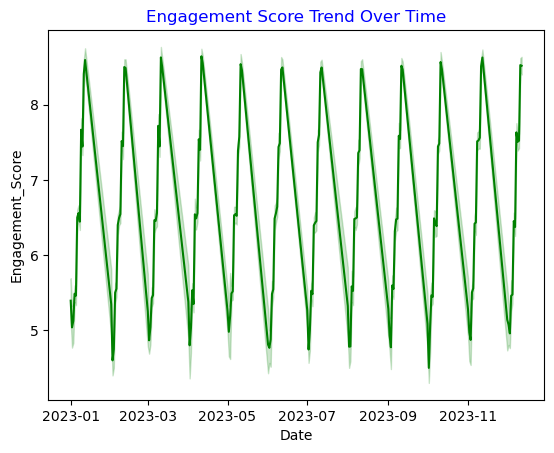

In [31]:
sns.lineplot(data=df, x='Date', y='Engagement_Score', color='g')
plt.title('Engagement Score Trend Over Time',color='b')
plt.show()

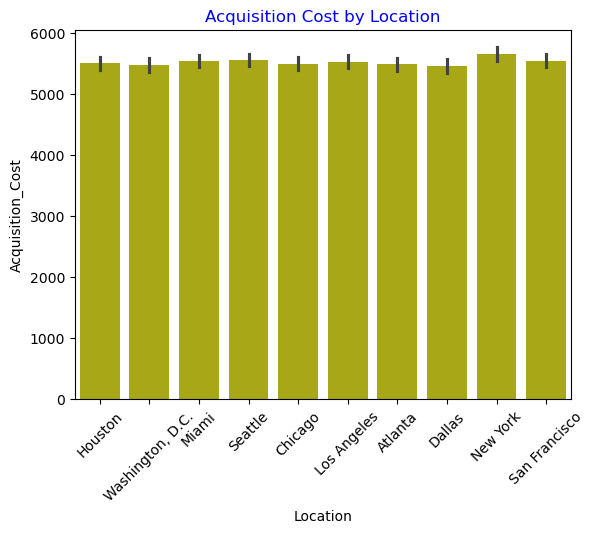

In [32]:
sns.barplot(data=df, x='Location', y='Acquisition_Cost',color='y')
plt.title('Acquisition Cost by Location', color='b')
plt.xticks(rotation=45)
plt.show()

C:\Users\sitha\AppData\Local\Temp\ipykernel_22532\1353379336.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:g'` for the same effect.

  sns.barplot(data=df, x='Location', y='Conversion_Rate', hue='Target_Audience',color='g')


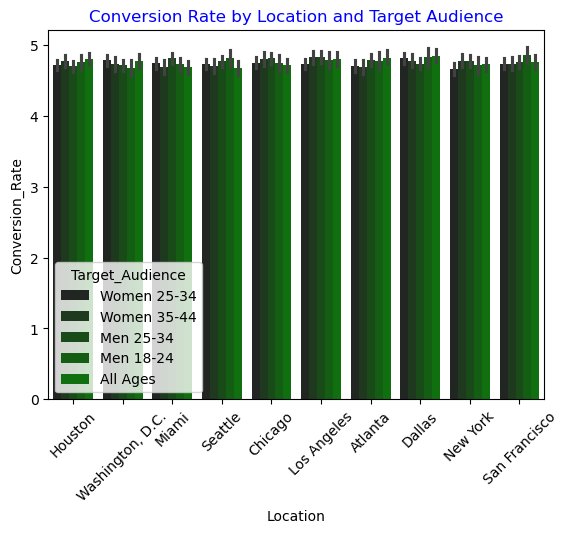

In [33]:
sns.barplot(data=df, x='Location', y='Conversion_Rate', hue='Target_Audience',color='g')
plt.xticks(rotation=45)
plt.title('Conversion Rate by Location and Target Audience',color='b')
plt.show()

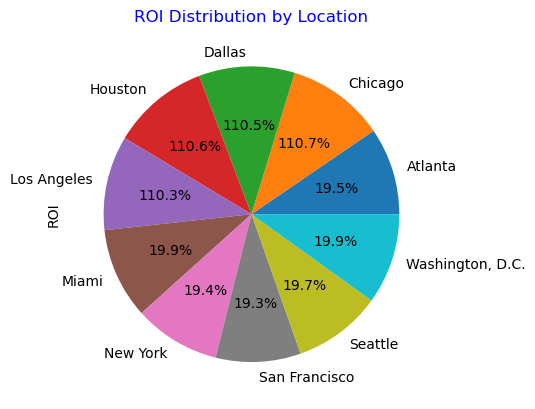

In [34]:
roi_by_location=df.groupby('Location')['ROI'].sum()
roi_by_location.plot.pie(autopct='1%.1f%%')
plt.title('ROI Distribution by Location', color='b')
plt.show()